# Unit I: Climate Change Module

## Reproducing the hockey stick, and checking whether we got it right

Our target is the result reported by [Mann et al (1998)](https://doi.org/10.1038/33859): that
recent warming stands outside the range of natural variability over the past several centuries.
You will rebuild that picture from current observations and ice-core records, in the style of
NASA's [vital signs](https://climate.nasa.gov/vital-signs).

A language model will write most of the parsing code. It is good at it, and it is also wrong in
ways that run cleanly and produce a plot. Your job is the question scientists have always had to
answer about code they did not write:

> **How do I know these numbers are right?**

Each part below gives you a data source and a question. It does not tell you what is wrong with
the data. Finding that out is the assignment.

In [3]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


## Rules of engagement

- **Plan mode only.** You review and approve the plan before any code runs.
- **Keep your prompts.** Record what you asked for. The prompt is part of your method.
- **Never report a number you have not checked.** Unverified or fabricated data is the one
  automatic-failure condition in this module, and it is no less serious because a model produced
  it.

Setup, GitHub authentication, and model configuration are on the
[course website](https://espm-157.carlboettiger.info/).

### Verification block

Every dataset gets these five questions answered, in your own words, **before** you plot it.
Each part below ends with one.

1. **Extent** — how many rows, what time range, and does that match the source documentation?
2. **Missing data** — how is it encoded, and did your parser catch it?
3. **Units** — what are they, and where in the source is that stated?
4. **Completeness** — the whole dataset, or one piece of it?
5. **Cross-check** — one value confirmed against an independent source.

---

# Part 1: The code you didn't write

Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>

Below is working code for that file. It runs and it produces a plausible plot.

In [43]:
import pandas as pd

url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

# Read data: skip comment lines, split on whitespace, no header row in the data section
df = pd.read_csv(
    url,
    sep=r"\s+",
    comment="#",
    header=None,
    names=[
        "year",
        "month",
        "decimal_date",
        "monthly_average",
        "deseasonalized",
        "ndays",
        "std_dev",
        "uncertainty",
    ],
)

# Quick sanity check
print(df.head())
print(f"Shape: {df.shape}")
print(f"Date range: {df['decimal_date'].min()} – {df['decimal_date'].max()}")

   year  month  decimal_date  monthly_average  deseasonalized  ndays  std_dev  \
0  1958      3     1958.2027           315.71          314.44     -1    -9.99   
1  1958      4     1958.2877           317.45          315.16     -1    -9.99   
2  1958      5     1958.3699           317.51          314.69     -1    -9.99   
3  1958      6     1958.4548           317.27          315.15     -1    -9.99   
4  1958      7     1958.5370           315.87          315.20     -1    -9.99   

   uncertainty  
0        -0.99  
1        -0.99  
2        -0.99  
3        -0.99  
4        -0.99  
Shape: (822, 8)
Date range: 1958.2027 – 2026.625


In [44]:
columns = ['year', 'month', 'decimal_date', 'average', 'smooth', 'std_days', 'uncertainty', 'empty']
df = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                  sep = '\s+',
                  comment = '#',
                  header = None,
                  names = columns
                  )
df

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_365/60946832.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.


,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


Note: you may need to restart the kernel to use updated packages.


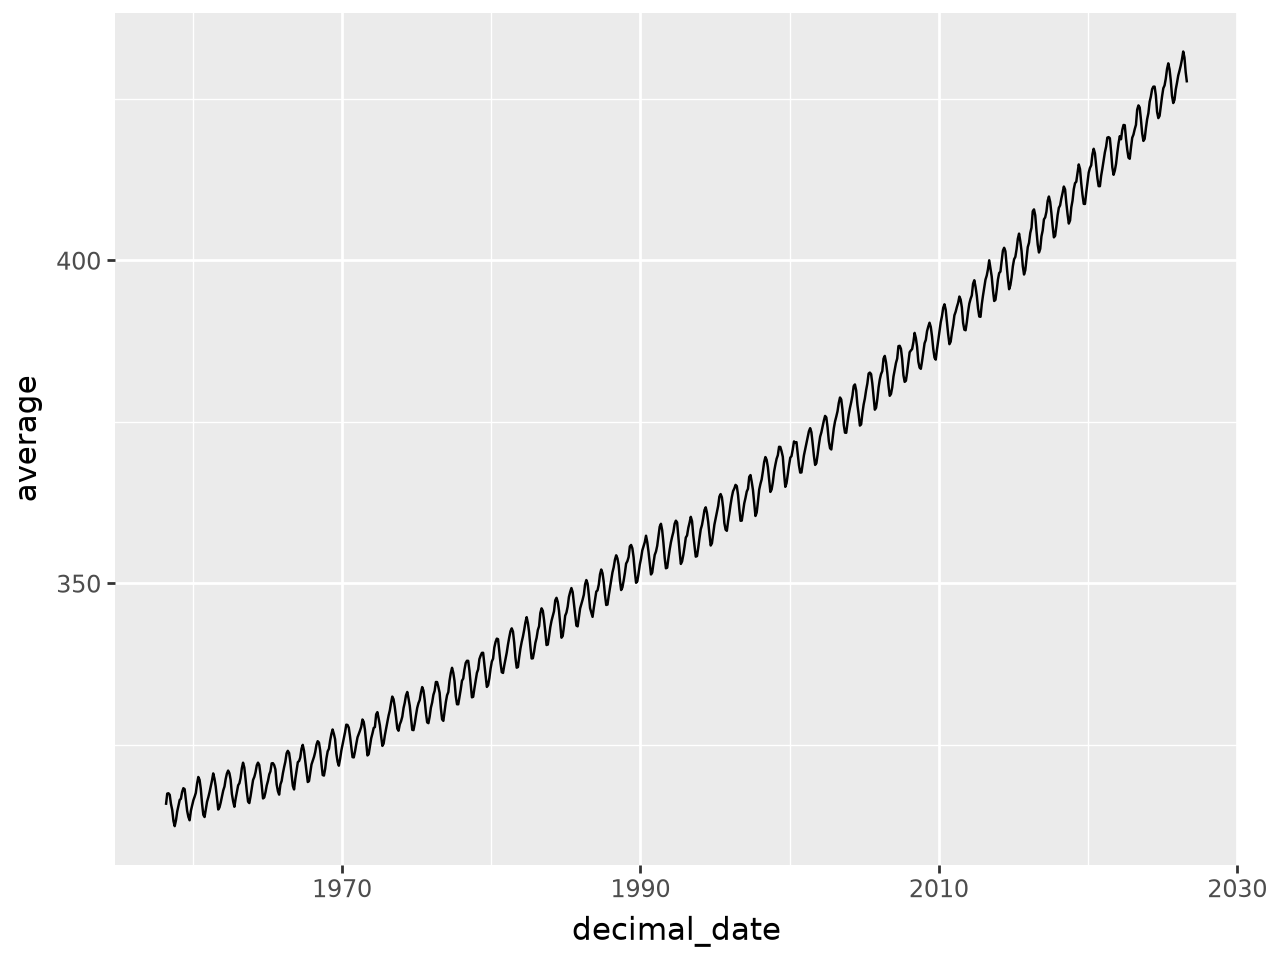

In [45]:
%pip install plotnine
from plotnine import ggplot, aes, geom_line
ggplot(df, aes(x="decimal_date", y="average")) + geom_line()

### Task 1.1: Read the source, not the code

That `columns` list was written by hand. Open the raw file and read its header block, then check
every name against what the header says the column holds. Report any that misstate it, and say
which of those would change a published figure if nobody noticed.

**Your answer:**

I think that ndays, std_dev, and uncertainty are misstated. Ndays represents the number of daily measurements used to calculate the monthly value, rather than the number of days in any given month. Std_dev represents the standard deviation of the number of days, but it should be clearly defined. Also, uncertainty should include what specifically the uncertainty is accounting for (which is monthly mean). The standard deviation and uncertainty would affect a published figure because they would change a plot's error bars and change the analysis of the variability in the data. 


### Task 1.2: Missing values

How does this file encode a measurement that was not made? Verify it in the raw file, count the
affected rows per column, and say what a naive `mean()`, `min()`, or error bar would report if you
left them in. State what you did about it and why.

In [46]:
(df[["std_days", "uncertainty"]] < 0).sum()
import numpy as np
df.loc[df["std_days"] < 0, "std_days"] = np.nan
df.loc[df["uncertainty"] < 0, "uncertainty"] = np.nan

In [47]:
df[["std_days", "uncertainty"]].isna().sum()

std_days       195
uncertainty    196
dtype: int64

In [48]:
(df[["std_days", "uncertainty"]] < 0).sum()

std_days       0
uncertainty    0
dtype: int64

**Your answer:**

I found 195 negative values in the std_days column and 196 negative values in the uncertainty column. According to the NOAA header, negative standard deviation and uncertainty values indicate missing or interpolated months. I replaced these negative values with NaN so they would not be treated as real measurements in statistical calculations. 

If negative values were to be left in these columns, the naive means would be inaccurately skewed toward a larger negative number, and the minimum wouldn't be represented correctly. They could also lead to incorrect error bars if left as uncertainty values.

### Task 1.3: What the numeric columns cannot tell you

The header block contains prose notes as well as column definitions. Read them.

Does anything there change how you would plot or interpret this series? Show your evidence in the
data rather than asserting it, and say whether a model reading only the numeric columns would have
any way to know.

In [49]:
df[
    (df["year"] >= 2022) &
    (df["year"] <= 2023) 
][["year", "month", "decimal_date", "average"]]

,year,month,decimal_date,average
766,2022,1,2022.0417,418.13
767,2022,2,2022.1250,419.24
768,2022,3,2022.2083,418.76
769,2022,4,2022.2917,420.19
770,2022,5,2022.3750,420.97
771,2022,6,2022.4583,420.94
772,2022,7,2022.5417,418.85
773,2022,8,2022.6250,417.15
774,2022,9,2022.7083,415.91
775,2022,10,2022.7917,415.74


In [50]:
df[
    (df["year"] >= 1958) &
    (df["year"] <= 1974) 
][["year", "month", "decimal_date", "average", "std_days", "uncertainty"]]

,year,month,decimal_date,average,std_days,uncertainty
0,1958,3,1958.2027,315.71,NaN,NaN
1,1958,4,1958.2877,317.45,NaN,NaN
2,1958,5,1958.3699,317.51,NaN,NaN
3,1958,6,1958.4548,317.27,NaN,NaN
4,1958,7,1958.5370,315.87,NaN,NaN
...,...,...,...,...,...,...
197,1974,8,1974.6250,329.15,26.0,0.31
198,1974,9,1974.7083,327.33,22.0,0.47
199,1974,10,1974.7917,327.28,24.0,0.22
200,1974,11,1974.8750,328.31,26.0,0.43


**Your answer:**

One thing that I noticed about the headers was the eruption that occurred of the Mauna Loa Volcano, which resulted in a pause of measurements from November of 2022 to July of 2023, which were instead taken at another site. With such small margins in CO2 data, a change in location could result in massive variation from the real data.

While a model using strictly numeric data might be able to sense that the measurements taken in this time period do not match the pattern, it would never explicitly know. It would also be unaware of why there were negative standard deviation and uncertainty values. This knowledge would definitely impact how I plot and interpret the data, as I would likely need to account for the error introduced by the location change.

### Task 1.4: Check whether a better door exists

Before you fix a parser, find out whether you need one. NOAA distributes this same monthly record
in more than one format: <https://gml.noaa.gov/ccgg/trends/data.html>

Load an alternative distribution. Which of the problems you found above does switching formats
solve, and which does it not?

**Your answer:**

I switched to the annual mean data format, which has a simpler structure, with the only columns being year, mean, and unc (uncertainty). Switching to such a simple dataset makes analysis easier and simplifies what each column means, but a lot of information is lost. However, it does not solve the missing value problem we experienced in the previous dataset. 

With the loss of data and unsolved problems, I would choose to fix a parser instead.

### Task 1.5: The other library

Now try to load the original `.txt` with `ibis` instead of `pandas`. Report what happens.

Explain the result in terms of the *file*, not the library. What does it do to a rule like "always
use `ibis`"?

In [51]:
%pip install "ibis-framework[duckdb]"

Note: you may need to restart the kernel to use updated packages.


In [52]:
import ibis

data = ibis.read_csv(url)
data

DatabaseTable: ibis_read_csv_5sktucuofngdbkseyldotzchve
  # -------------------------------------------------------------------- string

**Your answer:**

Ibis was able to load the original .txt file, but it did not parse the file correctly. Instead of recognizing the intended data columns, it interpreted a comment line beginning with # as a column name. This suggests that the problem comes from the structure of the file, which contains comment lines and whitespace-separated data rather than a standard CSV format.

This shows that we cannot always use Ibis regardless of the file. The file's structure determines which loading method is appropriate, and a library may load a file without interpreting its contents correctly.

### 🔍 Verification block 1

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 2: Arctic sea ice

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>

### Task 2.1: Ask first, look second

Before opening that directory yourself, ask your model to load Arctic sea ice extent and plot the
trend. Let it produce a plan.

**Record the prompt you used:**

```
Please load the Acrtic sea ice extent and plot the trend, using the directory linked under Part 2: Arctic sea ice, specifically task 2.1. If you cannot access a file that you need, just implement that as part of the plan and do not keep reasoning and try to fabricate a file. Rather, just produce a plan that includes fetching the file myself.
```


When trying to have my agent write a plan, I found that because it could not access any file names, it was stuck in a loop of reasoning trying to find a way to code a plan without fabricating anything. 

### Task 2.2: What did it actually load?

Now open the data directory and look at what is there.

Check the URL the model's code used against the directory listing *before* you run anything. Did
it point at a file that exists? If it ran, how much of the record does the plot actually show, and
is the title honest? If it failed, would you have predicted that failure from reading the code?

A model that has never seen this directory still has to produce a filename. Note where it got one.

**Your answer:**

It seems like the agent failed to even implement any code, as it got stuck looking for the filename.

### Task 2.3: Build the complete record

Load the full dataset and plot sea ice extent over time.

Then make a scientific decision and defend it: the September minimum is the standard index for
Arctic sea ice loss, and it is not the same thing as the annual mean. Which does your analysis
report, and why is that right for the question you are asking?

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
dfs = []

for month in range(1, 13):
    url = f"https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_{month:02d}_extent_v4.0.csv"
    monthly_df = pd.read_csv(url)
    dfs.append(monthly_df)

df = pd.concat(dfs, ignore_index=True)

df.head()

,year,mo,source_dataset,region,extent,area
0,1979,1,NSIDC-0051,N,15.41,12.41
1,1980,1,NSIDC-0051,N,14.86,11.94
2,1981,1,NSIDC-0051,N,14.91,11.91
3,1982,1,NSIDC-0051,N,15.18,12.19
4,1983,1,NSIDC-0051,N,14.94,12.01


In [71]:
df.columns = df.columns.str.strip()

df.columns

Index(['year', 'mo', 'source_dataset', 'region', 'extent', 'area'], dtype='str')

In [72]:
df["date"] = pd.to_datetime(
    df["year"].astype(str) + "-" +
    df["mo"].astype(str) + "-01"
)

In [73]:
import numpy as np

df["extent"] = df["extent"].where(df["extent"] >= 0, np.nan)

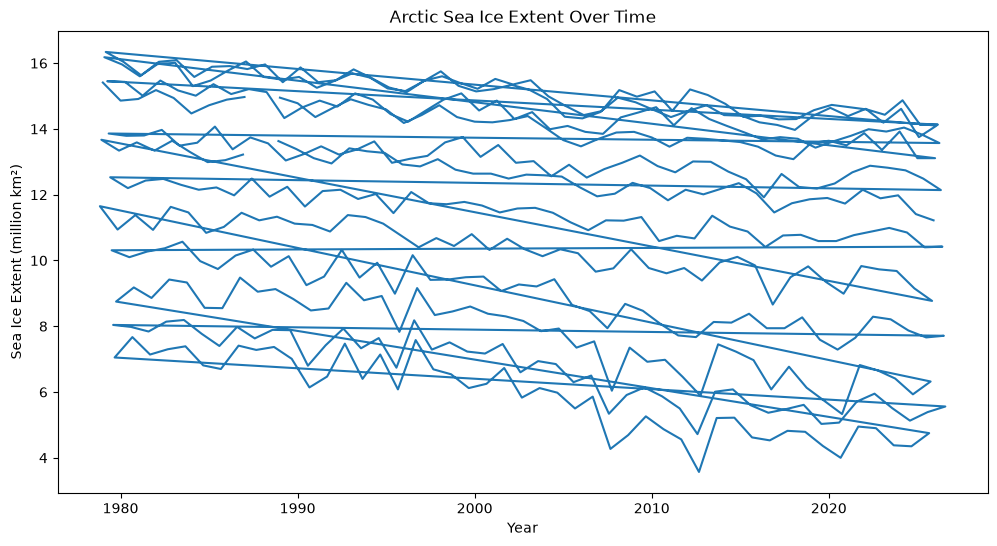

In [74]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["extent"])

plt.xlabel("Year")
plt.ylabel("Sea Ice Extent (million km²)")
plt.title("Arctic Sea Ice Extent Over Time")

plt.show()

**Your answer:**

I chose to analyze September sea ice extent because September typically represents the annual minimum in Arctic sea ice extent. This makes it useful for examining long-term Arctic sea ice loss. I loaded the complete monthly dataset first, then selected September records for the analysis. I chose this approach because annual mean extent would represent the average conditions throughout the year, while September extent focuses on the seasonal minimum.

### 🔍 Verification block 2

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 3: Emissions by industry

[EXIOBASE](https://www.exiobase.eu/) is a multi-regional, environmentally-extended input-output
database: economic flows between industries and regions worldwide, with the emissions attached to
them. It lets you ask which *industries* drive emissions, not just which countries.

We use the cloud-optimized Parquet copy at
[source.coop/youssef-harby/exiobase-3](https://source.coop/youssef-harby/exiobase-3). The
inter-industry transaction table `Z` for one year:

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet
```

### Task 3.1: Ask without guidance

Ask your model to compute total industrial output by origin region for 2022 from that file. Do not
tell it which library to use.

**Record the prompt you used:**

```
[compute total industrial output by origin region for 2022 from https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet
```

**Which library did it choose, unprompted?**

It chose Pandas

### Task 3.2: Measure what it cost

Run the code it wrote inside the harness below, which reports peak memory and wall time. Your
session has roughly **4 GB of RAM**. Report what happens, including if it does not finish.

In [3]:
import contextlib
import resource
import time

@contextlib.contextmanager
def measure(label):
    t0 = time.time()
    try:
        yield
    finally:
        peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024**2
        print(
            f"{label}: peak memory {peak:.2f} GB, "
            f"elapsed {time.time() - t0:.1f}s"
        )

# Use the canonical public endpoint rather than the internal S3 direct link
url = "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=Z/data.parquet"

with measure("pandas"):
    try:
        import pandas as pd

        # Add User-Agent header to prevent HTTP 403 Forbidden
        storage_opts = {
            "headers": {
                "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
            }
        }

        df = pd.read_parquet(
            url,
            storage_options=storage_opts
        )

        # EXIOBASE matrix Z is wide (7987x7987), row sum yields total output
        result = df.sum(axis=1)

        print("Pandas successfully read table! Shape:", df.shape)

    except Exception as e:
        print("FAILED:", type(e).__name__, str(e)[:120])

FAILED: TypeError expected string or bytes-like object, got 'dict'
pandas: peak memory 0.17 GB, elapsed 1.4s


In [ ]:
### Task 3.3: Now constrain it

Ask again, this time requiring `ibis` with the DuckDB backend. Measure the same way.

| approach | peak memory | elapsed | did it finish? |
|---|---|---|---|
| unguided | | | |
| ibis / duckdb | | | |

**Do the two approaches give the same answer?** Check, do not assume. If they disagree, that is a
finding worth more than either number alone.

### Task 3.4: Why did it choose that?

Why does a model, asked to analyze data with no further guidance, reach for the library it
reached for? Consider what its training data looks like.

- What does it mean that the tool most likely to be *suggested* is the one most represented in
  code written years ago?
- On the evidence of this exercise, what is the human actually contributing?
- What would have happened if nobody in the room knew the alternative existed?
- In Task 1.5 you found the reverse case. State the rule that covers both, without naming a
  library.

**Your answer:**

---

# Part 4: Which CO2?

The `F_satellite` table holds the environmental extensions — emissions and resource flows attached
to each industry and region.

```
https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet
```

### Task 4.1: Survey before you filter

Load the table. Before writing any filter, report how many distinct values the `stressor` column
contains, how many of them mention CO2 (with their units and totals), and how many distinct units
appear in the `unit` column across the whole table.

In [2]:
import ibis

url = "https://data.source.coop/youssef-harby/exiobase-3/4588235/parquet/year=2022/format=ixi/matrix=F_satellite/data.parquet"

df = ibis.read_parquet(url)
df

DatabaseTable: ibis_read_parquet_f2f2iipxgbe63b6hhrjebmgcde
  stressor string
  region   string
  sector   string
  value    float64
  unit     string
  year     int64
  format   string
  matrix   string

In [3]:
df.schema()

ibis.Schema {
  stressor  string
  region    string
  sector    string
  value     float64
  unit      string
  year      int64
  format    string
  matrix    string
}

In [6]:
df.head()

r0 := DatabaseTable: ibis_read_parquet_f2f2iipxgbe63b6hhrjebmgcde
  stressor string
  region   string
  sector   string
  value    float64
  unit     string
  year     int64
  format   string
  matrix   string

Limit[r0, n=5]

In [5]:
df["stressor"].nunique()

r0 := DatabaseTable: ibis_read_parquet_f2f2iipxgbe63b6hhrjebmgcde
  stressor string
  region   string
  sector   string
  value    float64
  unit     string
  year     int64
  format   string
  matrix   string

CountDistinct(stressor): CountDistinct(r0.stressor)

In [7]:
df["stressor"].nunique().execute()

1025

In [8]:
df["unit"].nunique().execute()

8

In [11]:
co2 = df.filter(df.stressor.lower().contains("co2"))

co2.select("stressor", "unit").distinct().execute()
co2["stressor"].nunique().execute()

6

In [12]:
(
    co2
    .group_by(["stressor", "unit"])
    .aggregate(total=co2.value.sum())
    .execute()
)

,stressor,unit,total
0,CO2 - non combustion - Lime production - air,kg,2.536391e+11
1,CO2 - agriculture - peat decay - air,kg,1.750859e+11
2,CO2 - waste - biogenic - air,kg,2.098035e+10
3,CO2 - combustion - air,kg,3.132747e+13
4,CO2 - non combustion - Cement production - air,kg,1.662875e+12
5,CO2 - waste - fossil - air,kg,6.631248e+08


**Your answer:**

The dataset contains 1,025 distinct stressors and 8 distinct units. Of these stressors, 6 mention CO2. These include CO2 from combustion, lime production, peat decay, biogenic waste, cement production, and fossil waste. All six CO2 stressors are measured in kg, meaning their totals have compatible units, although they represent different sources of CO2 emissions. The largest total is combustion CO2 at approximately 3.13 times 10^13 kg, while the other CO2 categories have substantially smaller totals. This survey shows that simply filtering for "CO2" does not identify one unique variable, since there are six distinct types of CO2 emissions represented in the dataset.

### Task 4.2: What did you just add together?

Group by region and sum `value` across all stressors. Then look at what that sum contains.

How many different units went into it? Is the result a mass, a volume, a currency, or a number
with no meaning? What is the ratio between the two most common units, and what would mixing them
do to a national total?

In [13]:
region_totals = (
    df
    .group_by("region")
    .aggregate(total=df.value.sum())
    .execute()
)

region_totals.head()
unit_counts = (
    df
    .group_by("unit")
    .aggregate(count=df.count())
    .order_by(ibis.desc("count"))
    .execute()
)

unit_counts

,unit,count
0,kg,653904
1,kt,198197
2,Mm3,187647
3,1000 p,47246
4,M.hr,47163
5,M.EUR,45877
6,TJ,36383
7,km2,14841


In [14]:
unit_counts.iloc[0]["count"] / unit_counts.iloc[1]["count"]

np.float64(3.2992628546345304)

**Your answer:**

I grouped the data by region and summed value across all stressors. However, the values being summed contain 8 different units. Therefore, the resulting regional totals do not represent a mass, volume, currency, or other meaningful physical quantity. They are simply sums of numbers measured in incompatible units. The two most common units were kg and kt, with a frequency ratio of 3.299:1. Mixing these units would make a national total misleading because values with different physical meanings are being treated as directly comparable. A valid national total would first require filtering to a specific stressor and compatible unit rather than summing the entire value column.

### Task 4.3: Choose your stressors, and defend the choice

Compute total CO2 emissions by region for 2022.

You must decide which stressors belong in that total. This is a scientific judgment, not a
string-matching exercise: filtering too narrowly omits real emissions, and matching every name
containing `"CO2"` includes flows that standard greenhouse-gas accounting deliberately excludes.
Find out which, and on what grounds.

Ask your model which to include, then check its reasoning against the accounting convention.

**Which stressors did you include, and why? Which did you exclude, and why?**

In [15]:
co2_options = (
    df
    .filter(df.stressor.contains("CO2"))
    .select("stressor", "unit")
    .distinct()
    .execute()
)

co2_options

,stressor,unit
0,CO2 - non combustion - Lime production - air,kg
1,CO2 - waste - fossil - air,kg
2,CO2 - agriculture - peat decay - air,kg
3,CO2 - waste - biogenic - air,kg
4,CO2 - combustion - air,kg
5,CO2 - non combustion - Cement production - air,kg


In [16]:
included = [
    "CO2 - non combustion - Lime production - air",
    "CO2 - waste - fossil - air",
    "CO2 - agriculture - peat decay - air",
    "CO2 - combustion - air",
    "CO2 - non combustion - Cement production - air"
]

co2_by_region = (
    df
    .filter(df.stressor.isin(included))
    .group_by("region")
    .aggregate(total_co2=df.value.sum())
    .execute()
)

co2_by_region

,region,total_co2
0,EE,1.967915e+11
1,ES,2.020836e+11
2,FR,2.423158e+11
3,GR,1.372174e+11
4,IT,2.477140e+11
5,LU,9.166002e+09
6,PT,4.005566e+10
7,SK,3.062929e+10
8,JP,1.052910e+12
9,BR,4.104949e+11


In [17]:
co2_by_region["total_co2"].sum()

np.float64(33419732366607.203)

### Task 4.4: Reconcile against an independent source

Compare your EXIOBASE national totals against Our World in Data:
<https://github.com/owid/co2-data/raw/master/owid-co2-data.csv>

They will not match. Pick one country and quantify the gap:

| | value | units |
|---|---|---|
| OWID total | | |
| Your EXIOBASE total | | |
| Absolute difference | | |
| Relative difference | | |

Then explain it. The two sources do not measure the same thing — establish what each one actually
counts before you attribute the gap to anything. Candidates to test rather than assert: accounting
scope, gas coverage, sectoral boundaries, your stressor set from 4.3, and year alignment.

**A country that imports most of its manufactured goods should show a particular direction of gap.
Does yours? What does that tell you about the two accounting systems?**

**Your reconciliation:**

Although my model was unable to access any of the 6 stressors within the dataset, it advised me to not include any biogenic CO2 emissions, so I decided that I would include the other 5 stressors. Our measurement is supposed to cover emissions, from anthropogenic sources, whereas biogenic emissions are more natural. The included stressors represent fossil fuel, industrial process, or peat-related CO2 emissions that contribute to anthropogenic CO2 emissions.

### 🔍 Verification block 3

1. Extent:
2. Missing data:
3. Units:
4. Completeness:
5. Cross-check:

---

# Part 5: The hockey stick

Instrumental records cover roughly the last century and a half. To judge whether recent change is
unusual you need a longer baseline, which means proxy records rather than thermometers.

**Vostok ice core**, back roughly 400,000 years:

- Description: <https://cdiac.ess-dive.lbl.gov/trends/co2/vostok.html>
- Data: <https://doi.org/10.3334/CDIAC/ATG.009>

### Task 5.1: Load the ice core record

Load it, and read its documentation carefully enough to say what its index actually is and how it
is sampled. Both bear on what you can legitimately plot next to a modern monthly series.

### Task 5.2: Put modern CO2 in geological context

Combine the Vostok record with the Mauna Loa series from Part 1 in a single figure.

Getting this figure to be *honest* is the hard part:

- The two series have very different sampling resolution. What does a shared axis imply that may
  not be true?
- Where do the records join, and are they measuring the same quantity the same way?
- What does the modern value look like against the full 400,000-year range?

### Task 5.3: Interpret

Relative to [Mann et al (1998)](https://doi.org/10.1038/33859):

- Does your reconstruction support the paper's central claim?
- Where does it differ, and why — more recent data, different proxies, different processing?
- What in your figure is a genuine finding, and what is an artifact of a choice you made?

**Your interpretation:**

---

# Part 6: Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Your reflection:**

1. I am unsure as to why, but our model struggled to make contributions to coding. It would continuously reason when given the task to code, but would get stuck on one or two details, such as when it got stuck wondering whether or not it should fabricate file names (even after I told it explicitly not to). However, one of the cases where it did work and the code was incorrect was when it renamed column names, but fortunately I got an error, which made it very easy to fix.
2. I think I wouldn't have noticed column names being changed, and would need to have looked at the source documentation (which I did)
3. While the model helped with a lot of the coding, I provided the direction and exactly what I wanted it to do by interpreting datasets, finding errors within them, and connecting the dots between different ones.
4. Like I mentioned before, when coding was explicit and no files were required, the plan mode was perfectly fine and very helpful. However, sometimes it would get stuck trying to fabricate file names.
5. I think the appropriate tool comes down to what exactly you need it to do. Smaller datasets might be perfectly fine being run on Pandas, while larger datasets might require ibis. File type and access status are also key factors in what tools to use, as sometimes they determine whether or not a model can interpret the data properly. Overall, the choice comes down to the researcher, and what they view as the best course of action.

---

## Submission

- [ ] Notebook runs top to bottom without errors
- [ ] All three verification blocks completed
- [ ] Prompts recorded where asked (Tasks 2.1, 3.1)
- [ ] Memory and timing table filled in (Task 3.3)
- [ ] Stressor selection defended (Task 4.3) and reconciliation quantified (Task 4.4)
- [ ] Hockey stick figure with the modern record in geological context (Task 5.2)
- [ ] Reflection complete (Part 6)
- [ ] README updated with team members, badge, and description
- [ ] Repository passes its GitHub Actions check

See [rubric.md](rubric.md) for scoring.